<a href="https://colab.research.google.com/github/Shinyhunter95/Masters-Project/blob/main/AR(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

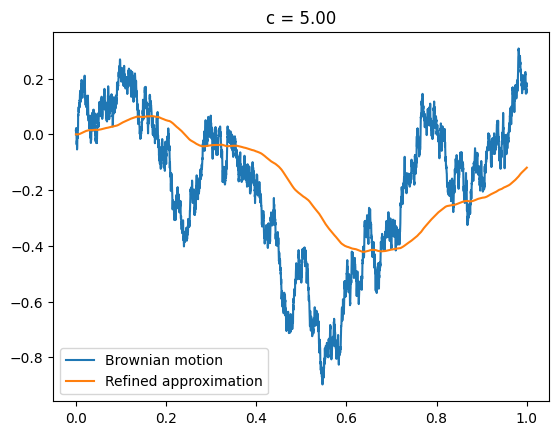

sup |W(t)| = 0.897409139865374
sup |X(t)| = 0.42155549178169216
sup |OU term| 0.5931162191273796


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000

a = 5.0 # This determines c
rho = 1 - a/N

c = N * np.log(1/rho)

# time grid
t = np.linspace(0, 1, N)

# ---------------------------------
# Brownian motion
# ---------------------------------

dW = np.random.normal(0, 1/np.sqrt(N), N)
W = np.cumsum(dW)

# ---------------------------------
# OU correction term
# ---------------------------------

OU_term = np.zeros(N)

for k in range(N):

    tk = t[k]

    kernel = np.exp(-c * (tk - t[:k+1]))

    OU_term[k] = np.sum(kernel * dW[:k+1])

# ---------------------------------
# Approximation process
# ---------------------------------

X = W - OU_term

# ---------------------------------
# Plot
# ---------------------------------

plt.plot(t, W, label='Brownian motion')
plt.plot(t, X, label='Refined approximation')

plt.legend()
plt.title(f'c = {c:.2f}')
plt.show()

print("sup |W(t)| =", np.max(np.abs(W)))
print("sup |X(t)| =", np.max(np.abs(X)))
print("sup |OU term|", np.max(np.abs(OU_term)))

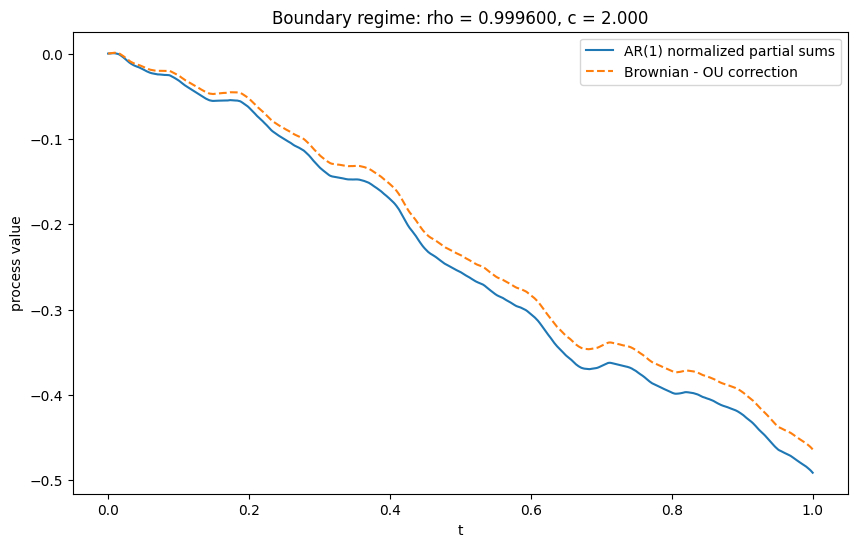

rho = 0.9996
c = 2.0004001066983528
sup |W(t)| = 0.9546512202014038
sup |OU term| = 0.7779730360313067
sup |Y - X| = 0.027351836495387527


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000

# Local-to-unity parameter
a = 2.0

# Boundary scaling
rho = 1 - a / N

# c_N = N log(1/rho_N)
c = N * np.log(1 / rho)

# Time grid
t = np.linspace(0, 1, N)

# ---------------------------------
# Innovations
# ---------------------------------

eps = np.random.randn(N)

# ---------------------------------
# Simulate AR(1)
# x_k = rho x_{k-1} + eps_k
# ---------------------------------

x = np.zeros(N)

for k in range(1, N):
    x[k] = rho * x[k-1] + eps[k]

# ---------------------------------
# Partial sums
# S_k = sum_{j=1}^k x_j
# ---------------------------------

S = np.cumsum(x)

# ---------------------------------
# Normalized process
# Y_N(t) = ((1-rho)/sqrt(N)) S(Nt)
# ---------------------------------

Y = (1 - rho) * S / np.sqrt(N)

# ---------------------------------
# Brownian motion approximation
# ---------------------------------

dW = eps / np.sqrt(N)

W = np.cumsum(dW)

# ---------------------------------
# OU correction term
# Gamma_c(t)
# ---------------------------------

OU_term = np.zeros(N)

for k in range(N):

    kernel = np.exp(-c * (t[k] - t[:k+1]))

    OU_term[k] = np.sum(kernel * dW[:k+1])

# ---------------------------------
# Refined approximation
# X(t) = W(t) - Gamma_c(t)
# ---------------------------------

X = W - OU_term

# ---------------------------------
# Error
# ---------------------------------

error = np.max(np.abs(Y - X))

# ---------------------------------
# Plot
# ---------------------------------

plt.figure(figsize=(10, 6))

plt.plot(t, Y, label='AR(1) normalized partial sums')

plt.plot(
    t,
    X,
    '--',
    label='Brownian - OU correction'
)

plt.legend()

plt.title(
    f'Boundary regime: rho = {rho:.6f}, c = {c:.3f}'
)

plt.xlabel('t')

plt.ylabel('process value')

plt.show()

# ---------------------------------
# Diagnostics
# ---------------------------------

print("rho =", rho)

print("c =", c)

print("sup |W(t)| =", np.max(np.abs(W)))

print("sup |OU term| =", np.max(np.abs(OU_term)))

print("sup |Y - X| =", error)